## Введение: 

### Поставленные задачи: 

- Составить портрет клиента нашего банка
- Создать модель для предсказания дефолта клиента по флагу Attrition_Flag (где Existing Customer - пользователь с открытым счетом, Attrition Customer - с заблокированым)
- Посмотреть распределение клиентов по различным признакам

### Шаги: 

- Первичный анализ датасета - смотрим на датасет, оцениваем данные, смотрим наличие null-значений, выбросов, ошибок в данных
- Смотрим распределение клиентов по признакам: возраст, количество иждевенцов, пол, уровень образования, статус, доход, тип карты.
- Создаем модель по которой предсказываем вероятность блокировки счета по тем пользователям у которых этот счет заблокирован. 

## Первичный анализ датасета 

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
df = pd.read_csv('BankChurners.csv')

df.head(10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311,0.000055,0.99994
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,...,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066,0.000123,0.99988
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,...,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048,0.000086,0.99991
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,...,22352.0,2517,19835.0,3.355,1350,24,1.182,0.113,0.000045,0.99996
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,...,11656.0,1677,9979.0,1.524,1441,32,0.882,0.144,0.000303,0.99970


## Заметим в таблице странные колонки

Т.к мы их не используем, то создадим новый датасет не включающий эти колонки

In [5]:
df1 = df[['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book']]

In [6]:
df1.head(10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36


## Первичная информация о таблице:

- CLIENTIUM - похоже на уникальный id для каждого пользователя, далее проверим его уникальность. 
- Attrition_Flag - информация о том закрыт ли счет в банке у клиента или нет (должно быть только 2 значения)
- Customer_Age - возраст клиента (должен быть вменяемым и реальным) 
- Gender - гендер (должно быть только 2 значения 
- Education_Level - уровень образования (должны быть перечислены строки с типом образования)
- Maritial_Status - брачный статус (все значения должны быть строки)
- Income_Category - Категория дохода пользователя
- Card_Category - тип карты
- Months_on_book - количество месяцев в течение которых пользователь пользуется, пользовался нашими услугами (должно быть число)

In [7]:
df1.info() # Ок, везде 10127 строк и нет Null значений 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CLIENTNUM        10127 non-null  int64 
 1   Attrition_Flag   10127 non-null  object
 2   Customer_Age     10127 non-null  int64 
 3   Gender           10127 non-null  object
 4   Dependent_count  10127 non-null  int64 
 5   Education_Level  10127 non-null  object
 6   Marital_Status   10127 non-null  object
 7   Income_Category  10127 non-null  object
 8   Card_Category    10127 non-null  object
 9   Months_on_book   10127 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 791.3+ KB


In [8]:
df1.describe() # Числовые данные на первый взгляд логически корректны 

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book
count,1.012700e+04,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409
std,3.690378e+07,8.016814,1.298908,7.986416
min,7.080821e+08,26.000000,0.000000,13.000000
25%,7.130368e+08,41.000000,1.000000,31.000000
50%,7.179264e+08,46.000000,2.000000,36.000000
75%,7.731435e+08,52.000000,3.000000,40.000000
max,8.283431e+08,73.000000,5.000000,56.000000


In [9]:
df1['CLIENTNUM'].unique # Все клиенты уникальные 

<bound method Series.unique of 0        768805383
1        818770008
2        713982108
3        769911858
4        709106358
           ...    
10122    772366833
10123    710638233
10124    716506083
10125    717406983
10126    714337233
Name: CLIENTNUM, Length: 10127, dtype: int64>

In [10]:
df1['Attrition_Flag'].unique() # только 2 категории текущий и ушедший пользователь

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [11]:
df1['Customer_Age'].describe() # смотрим распределение возраста 

count    10127.000000
mean        46.325960
std          8.016814
min         26.000000
25%         41.000000
50%         46.000000
75%         52.000000
max         73.000000
Name: Customer_Age, dtype: float64

In [12]:
df1['Customer_Age'].unique() # с возрастом все хорошо 

array([45, 49, 51, 40, 44, 32, 37, 48, 42, 65, 56, 35, 57, 41, 61, 47, 62,
       54, 59, 63, 53, 58, 55, 66, 50, 38, 46, 52, 39, 43, 64, 68, 67, 60,
       73, 70, 36, 34, 33, 26, 31, 29, 30, 28, 27])

## Посмотрим распределение кол-во клиентов по возрасту

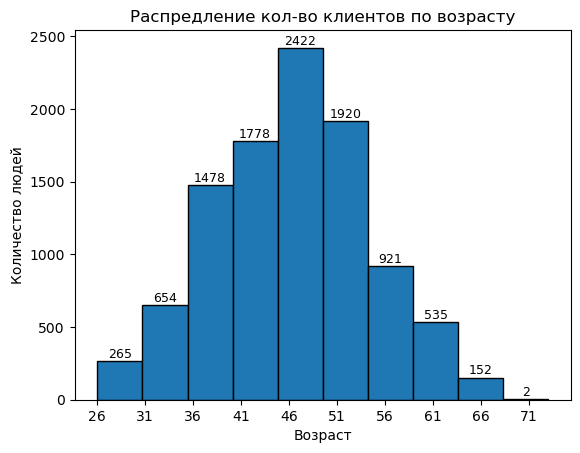

In [13]:
counts, bins, patches = plt.hist(df1['Customer_Age'], bins=10, edgecolor='black') 

plt.xlabel('Возраст')
plt.ylabel('Количество людей')

for i in range(len(counts)): 
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, # x
                counts[i] + max(counts)*0.001,  # Небольшое смещение вверх (y)
             str(int(counts[i])), 
                ha='center', 
                va='bottom',
                fontsize=9)

min_age = df1['Customer_Age'].min()
max_age = df1['Customer_Age'].max()

plt.xticks(range(min_age, max_age, 5))
plt.title('Распредление кол-во клиентов по возрасту')

plt.show()

In [14]:
df1['Dependent_count'].unique() # с количеством иждевенцов тоже все хорошо

array([3, 5, 4, 2, 0, 1])

## Распределение количества иждевенцов 

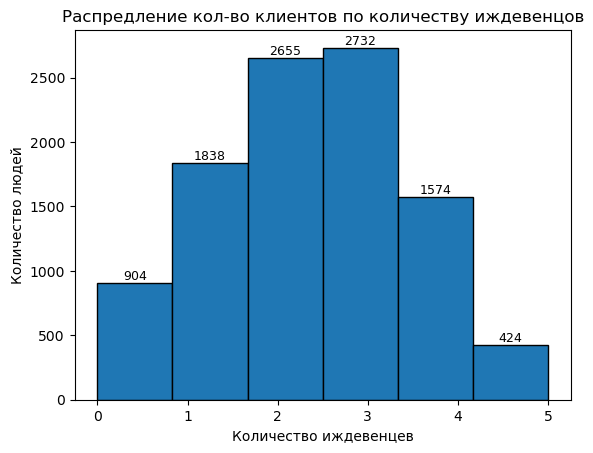

In [15]:
counts, bins, patches = plt.hist(df1['Dependent_count'], bins=6, edgecolor='black') # кол-во иждевенцев 

for i in range(len(counts)): 
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, # x
                counts[i] + max(counts)*0.001,  # Небольшое смещение вверх (y)
             str(int(counts[i])), 
                ha='center', 
                va='bottom',
                fontsize=9)

min_dependens = df1['Dependent_count'].min()
max_dependens = df1['Dependent_count'].max()


plt.xlabel('Количество иждевенцев')
plt.ylabel('Количество людей')
plt.title('Распредление кол-во клиентов по количеству иждевенцов')

plt.xticks(range(min_dependens, max_dependens + 1))

plt.show()

In [16]:
df1['Gender'].describe()

count     10127
unique        2
top           F
freq       5358
Name: Gender, dtype: object

In [17]:
df1['Gender'].unique() # с полом все ок 

array(['M', 'F'], dtype=object)

In [18]:
df1['Dependent_count'].describe()

count    10127.000000
mean         2.346203
std          1.298908
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: Dependent_count, dtype: float64

In [19]:
df1['Education_Level'].unique() 

array(['High School', 'Graduate', 'Uneducated', 'Unknown', 'College',
       'Post-Graduate', 'Doctorate'], dtype=object)

In [20]:
df1['Education_Level'].describe() # самое популярное образование 

count        10127
unique           7
top       Graduate
freq          3128
Name: Education_Level, dtype: object

## Заменяем значения Unknown на моду, т.к Education_Level - выражен категориальными данными

In [21]:
mode_education = df1['Education_Level'].mode()[0]

df1.loc[:, 'Education_Level'] = df1['Education_Level'].replace('Unknown', mode_education) # заменим неизвестное значение на модаьное

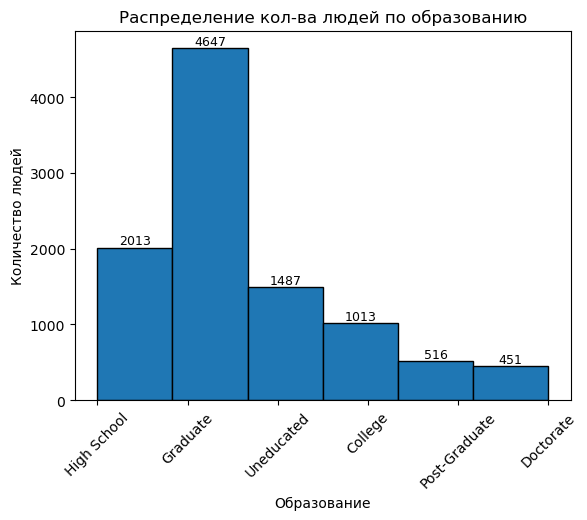

In [22]:
counts, bins, patches = plt.hist(df1['Education_Level'], bins=6, edgecolor='black') # большинство людей имеют степень бакалавра 
plt.xticks(rotation=45)

for i in range(len(counts)): 
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, # x
                counts[i] + max(counts)*0.001,  # Небольшое смещение вверх (y)
             str(int(counts[i])), 
                ha='center', 
                va='bottom',
                fontsize=9)

plt.title('Распределение кол-ва людей по образованию')
plt.xlabel('Образование')
plt.ylabel('Количество людей')

plt.show()

## Заменяем значения Unknown на моду, т.к Marital_Status - выражен категориальными данными

In [23]:
mode_status = df1['Marital_Status'].mode()[0]

df1.loc[:, 'Marital_Status'] = df1['Marital_Status'].replace('Unknown', mode_status) # заменяе значения Unknown на моду 

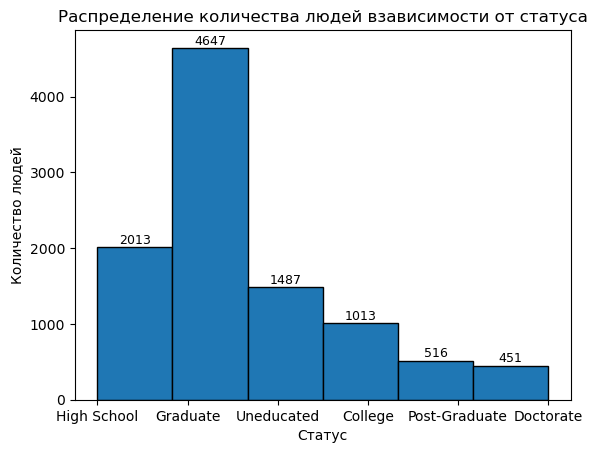

In [24]:
counts, bins, patches = plt.hist(df1['Education_Level'], bins=6, edgecolor='black') # большинство людей женаты

for i in range(len(counts)): 
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, # x
                counts[i] + max(counts)*0.001,  # Небольшое смещение вверх (y)
             str(int(counts[i])), 
                ha='center', 
                va='bottom',
                fontsize=9)
    
plt.title('Распределение количества людей взависимости от статуса')
plt.ylabel('Количество людей')
plt.xlabel('Статус')
plt.show()

## Заменяем значения Unknown на моду, т.к income_category - выражен категориальными данными

In [25]:
mode_income = df1['Income_Category'].mode()[0]

df1.loc[:, 'Income_Category'] = df1['Income_Category'].replace('Unknown', mode_income)

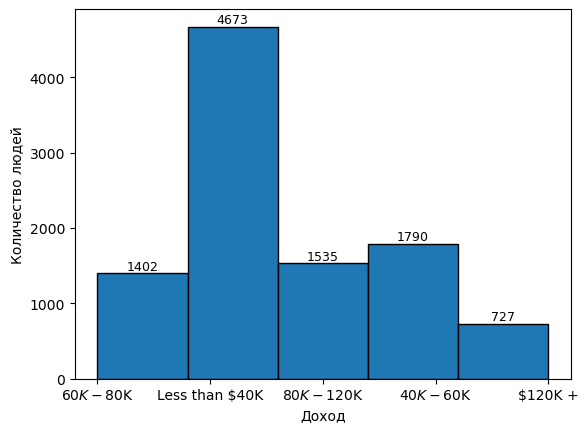

In [26]:
counts, bins, patches = plt.hist(df1['Income_Category'], bins=5, edgecolor='black') # большинство людей зарабатывают меньше чем 40к
for i in range(len(counts)): 
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, # x
                counts[i] + max(counts)*0.001,  # Небольшое смещение вверх (y)
             str(int(counts[i])), 
                ha='center', 
                va='bottom',
                fontsize=9)
    
plt.xlabel('Доход')
plt.ylabel('Количество людей')
plt.show()

In [27]:
df1.loc[:, 'Card_Category'].unique()

array(['Blue', 'Gold', 'Silver', 'Platinum'], dtype=object)

In [28]:
df1.loc[:, 'Card_Category'].describe()

count     10127
unique        4
top        Blue
freq       9436
Name: Card_Category, dtype: object

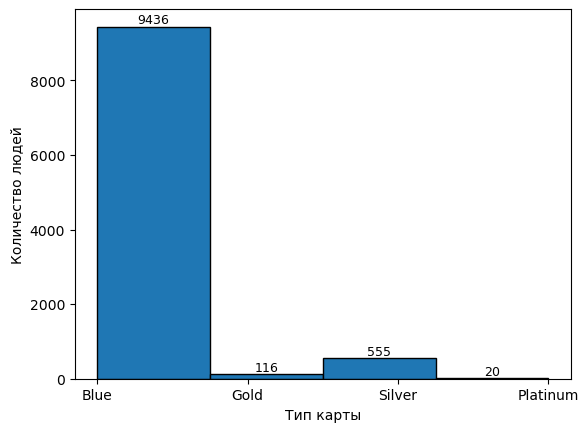

In [29]:
counts, bins, patches = plt.hist(df1.loc[:, 'Card_Category'], bins=4, edgecolor='black') # голубая карта самая популярная среди клиентов 

for i in range(len(counts)): 
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, # x
                counts[i] + max(counts)*0.001,  # Небольшое смещение вверх (y)
             str(int(counts[i])), 
                ha='center', 
                va='bottom',
                fontsize=9)
    
plt.xlabel('Тип карты')
plt.ylabel('Количество людей')
plt.show()

In [30]:
df1.loc[:, 'Months_on_book'].unique() # со значениями месяца все хорошо 

array([39, 44, 36, 34, 21, 46, 27, 31, 54, 30, 48, 37, 56, 42, 49, 33, 28,
       38, 41, 43, 45, 52, 40, 50, 35, 47, 32, 20, 29, 25, 53, 24, 55, 23,
       22, 26, 13, 51, 19, 15, 17, 18, 16, 14])

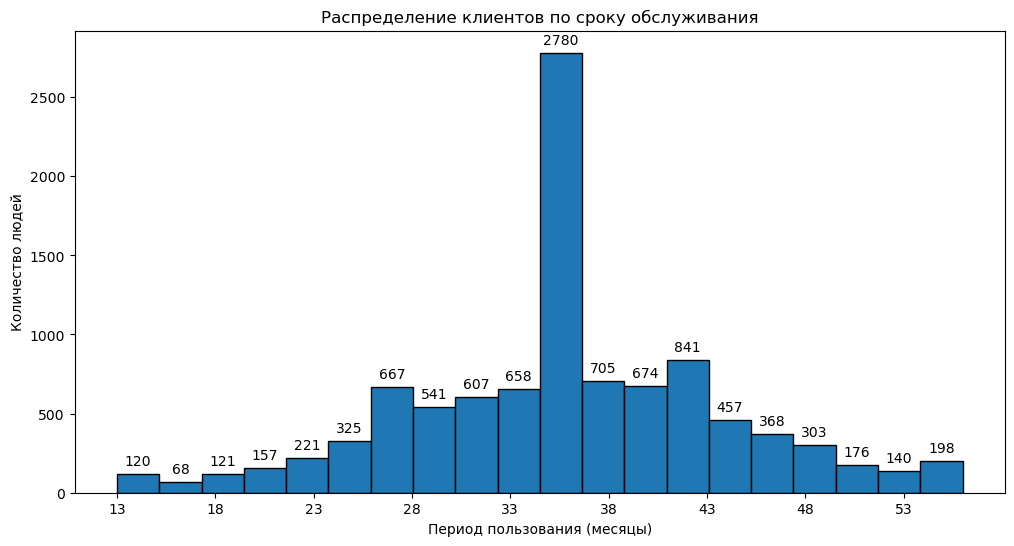

In [31]:
plt.figure(figsize=(12, 6))


counts, bins, patches = plt.hist(df1.loc[:, 'Months_on_book'], bins=20, edgecolor='black')

# Подписи значений над столбцами
for i in range(len(counts)):
    if counts[i] > 0:
        plt.text(bins[i] + (bins[i+1] - bins[i])/2,
                counts[i] + max(counts)*0.02,
                f'{int(counts[i])}',
                ha='center')

min_month = df1.loc[:, 'Months_on_book'].min()
max_month = df1.loc[:, 'Months_on_book'].max()

plt.xlabel('Период пользования (месяцы)')
plt.ylabel('Количество людей')
plt.title('Распределение клиентов по сроку обслуживания')
plt.xticks(range(min_month, max_month, 5))

plt.show()

По графику видно, что самое большое количество пользователей пользовались / пользуются нашим сервисом в районе 33 - 38 месяцев, следовательно при случайной выборке клиента банка будет высокая вероятность, что он пользуется сервисом в районе 35 месяцев по сравнению с другими месяцами, что показано отклонением значения количества людей на гистограме 

## Итоги первичного анализа: 

### Расчитываем вероятность банкротства. Модель RandomForestClassifier

### Т.к модель легче работать с цифрами, чем с строками, то нам нужно закодировать наши признаки для модели 

In [32]:
# Кодируем значения образования 
def education_encoded(education): 
    if education == 'Doctorate':
        return 6 
    elif education == 'Post-Graduate':
        return 5
    elif education == 'Graduate':
        return 4
    elif education == 'College':
        return 3
    elif education == 'High School':
        return 2
    else:  
        return 1

# Кодируем значения дохода
def income_encoded(income): 
    if income == '$120K +':
        return 5
    elif income == '$80K - $120K':
        return 4
    elif income == '$60K - $80K':
        return 3
    elif income == '$40K - $60K':
        return 2
    elif income == 'Less than $40K':
        return 1

# Кодируем значения типа карты 
def card_type_encoded(card): 
    if card == 'Gold':
        return 4
    elif card == 'Platinum':
        return 3
    elif card == 'Silver':
        return 2
    else:  
        return 1

def married_encoded(maritial): 
    if maritial == 'Married':
        return 2
    else: 
        return 1
df1.loc[:, 'Education_Level_encoded'] = df1['Education_Level'].apply(education_encoded)
df1.loc[:, 'Income_Category_encoded'] = df1['Income_Category'].apply(income_encoded)
df1.loc[:, 'Card_Category_encoded'] = df1['Card_Category'].apply(card_type_encoded)
df1.loc[:, 'Marital_Status_encoded'] = df1['Marital_Status'].apply(married_encoded)

C:\Users\Админ\AppData\Local\Temp\ipykernel_11460\1763246481.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.loc[:, 'Education_Level_encoded'] = df1['Education_Level'].apply(education_encoded)
C:\Users\Админ\AppData\Local\Temp\ipykernel_11460\1763246481.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.loc[:, 'Income_Category_encoded'] = df1['Income_Category'].apply(income_encoded)
C:\Users\Админ\AppData\Local\Temp\ipykernel_11460\1763246481.py:47: SettingWithCopyWarning: 
A value is trying 

In [33]:
df1.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Education_Level_encoded,Income_Category_encoded,Card_Category_encoded,Marital_Status_encoded
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,2,3,1,2
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,4,1,1,1
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,4,1,2
3,769911858,Existing Customer,40,F,4,High School,Married,Less than $40K,Blue,34,2,1,1,2
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,1,3,1,2


## Модель расчитывающая вероятность банкротства клиента по колонке Attrition_Flag

In [34]:
df1.loc[:, 'Attrition_Flag'].unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
# Передача данных 
X = df1[['Customer_Age', 'Dependent_count', 'Months_on_book', 'Education_Level_encoded',
        'Income_Category_encoded', 'Card_Category_encoded', 'Marital_Status_encoded']]
y = (df1['Attrition_Flag'] == 'Attrited Customer').astype(int)

# Обучение
model = RandomForestClassifier()
model.fit(X, y)

# Предсказание вероятности банкротства на тренировочных данных
predict_y = model.predict_proba(X)[:, 1]


df1.loc[:, 'default_probability'] = model.predict_proba(X)[:, 1]
# Процент *надежности клиента
df1.loc[:, 'credit_score_percent'] = (1 - df1['default_probability']) * 100 

accuracy = model.score(X, y)

print(f"Вероятность получить верное значение моделью на основе данных: {accuracy:.4f}")
print('\n')

roc_auc = roc_auc_score(y, predict_y)

print(f"ROC-AUC на данных: {roc_auc:.4f}") 

Вероятность получить верное значение моделью на основе данных: 0.9669


ROC-AUC на данных: 0.9949


## Вывод о модели: 

Как мы видим вероятность получения верных данных = 0.9669. Баланс между исходными данными и предсказаными  приближен к единице (0.9949).

In [86]:
df1.sample(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Education_Level_encoded,Income_Category_encoded,Card_Category_encoded,Marital_Status_encoded,default_probability,credit_score_percent
9977,711433908,Attrited Customer,41,F,3,Uneducated,Married,Less than $40K,Blue,30,1,1,1,2,0.695000,30.500000
4704,782548758,Existing Customer,42,F,5,High School,Divorced,Less than $40K,Blue,36,2,1,1,1,0.051667,94.833333
2737,708796458,Existing Customer,30,F,2,Graduate,Single,Less than $40K,Blue,18,4,1,1,1,0.030000,97.000000
1166,711957708,Existing Customer,38,F,2,Graduate,Married,Less than $40K,Blue,36,4,1,1,2,0.322286,67.771429
4456,780602733,Existing Customer,42,M,3,Uneducated,Single,$60K - $80K,Blue,30,1,3,1,1,0.080000,92.000000


## Построим гистограму распределения вероятности дефолта клиентов

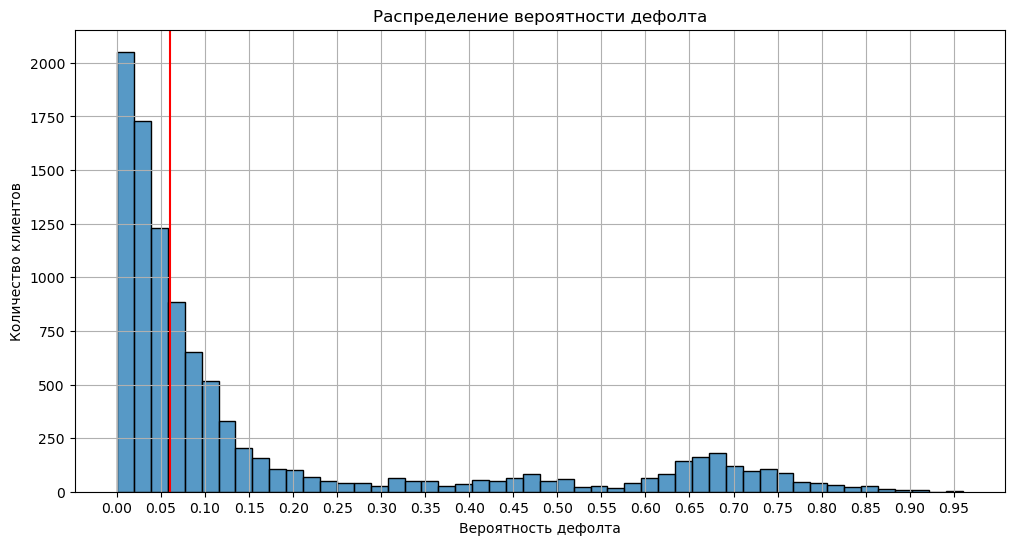

In [64]:
plt.figure(figsize=(12, 6))

sns.histplot(df1['default_probability'], bins=50)
median_area = df1['default_probability'].median()
plt.axvline(median_area, color='red')
plt.title('Распределение вероятности дефолта')
plt.xlabel('Вероятность дефолта')
plt.ylabel('Количество клиентов')
plt.xticks(np.arange(0, 1, 0.05))
plt.grid(True)

По графику видно, что средняя вероятность дефолта клиента равна 6 процентам. 

## Построим график распределение кредитного score клиентов

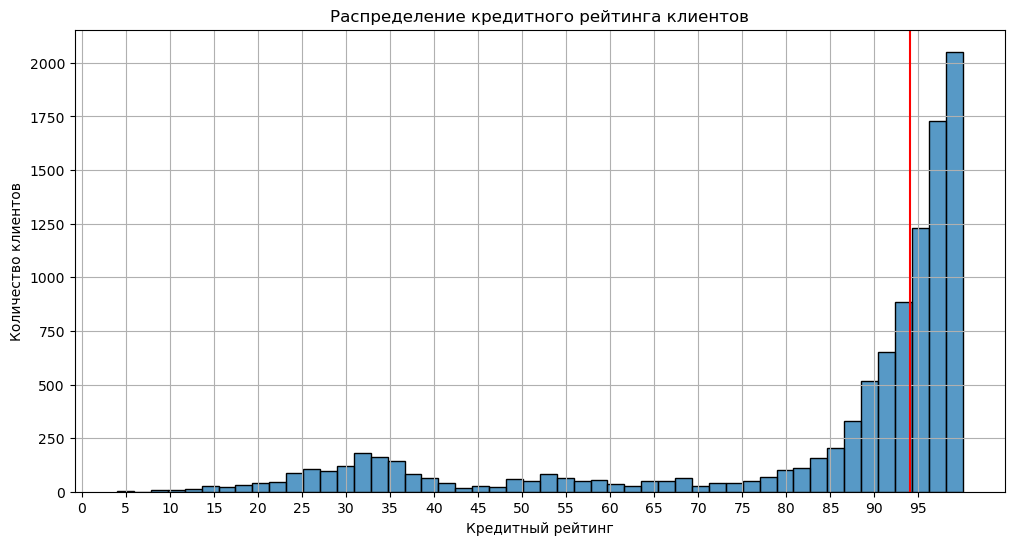

In [65]:
plt.figure(figsize=(12, 6))

sns.histplot(df1['credit_score_percent'], bins=50)
median_area = df1['credit_score_percent'].median()
plt.axvline(median_area, color='red')
plt.title('Распределение кредитного рейтинга клиентов')
plt.xlabel('Кредитный рейтинг')
plt.ylabel('Количество клиентов')
plt.xticks(np.arange(0, 100, 5))
plt.grid(True)

По графику видно,что достаточно много клиентов имеют высокий кредитный рейтинг 

## Итоги проделенной работы: 

### 1) Составлен портрет клиента нашего банка:
   - 1.Доход меньше 40K долларов 
   - 2.Средний возраст клиента 46 лет 
   - 3.Пол - женский 
   - 4.Кол-во иждевенцев у клиента 3 
   - 5.Образование клиента - бакалавр 
   - 6.Статус - женат/жената 
   - 7.Карта банка - голубая 
   - 8.Пользуется нашим банком где-то 35 месяцев
   
### 2) Составлена модель RandomForestClassifier, которая расчитывает вероятность банкротства клиента по флагу Attrition_Flag:
   - Вероятность получить верное значение моделью на основе данных: 0.9669
   - ROC-AUC оценка на данных: 0.9949
   - Получены довольно высокие оценки предсказаний модели

### 3) Построено распределение дефолта клиентов и кредитного рейтинга, найдена медианная вероятность дефолта клиента около 6%, средний кредитный рейтинг клиентов около 94%. 